# **Project:** Food Vision

In this we are going to train a model for recognizing the uamages of food

## Get the helper function

Some bunch of helper function are being ready to do small tasks


In [4]:
# Download the functions script
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2025-09-27 11:35:59--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2025-09-27 11:36:00 (127 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [10]:
# Import series of helper functions
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys,unzip_data,pred_and_plot,load_and_prep_image

## Use tensorflow dataset to download data

In [12]:
# Get tensflow dataset
import tensorflow_datasets as tfds

In [13]:
# List all available datasets
datasets_list=tfds.list_builders()
print("food101" in datasets_list)

True


In [14]:
# Load in the data
(train_data,test_data),ds_info=tfds.load(name="food101",split=["train","validation"],shuffle_files=True,as_supervised=True,with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.8QMCBD_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.8QMCBD_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


In [15]:
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [16]:
# Get the class names
class_names=ds_info.features["label"].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

## Exploring the Food101 data from tensorflow datasets

To become one with our data, we want to find:
* Class name
* The shape of our input data (image tensors)
* The datatype of our input data
* What the labels look like
* Do labels maths up with the class names

In [17]:
# Take one sample from out train data
train_one_sample=train_data.take(1)

In [18]:
# what does one sample of our training data look like
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [19]:
# Output info about our training sample
for image,labels in train_one_sample:
  print(f"Image shape: {image.shape}")
  print(f"Image datatype: {image.dtype}")
  print(f"Target class from Food101: {labels}")
  print(f"Class name (from Food101): {class_names[labels]}")


Image shape: (512, 512, 3)
Image datatype: <dtype: 'uint8'>
Target class from Food101: 23
Class name (from Food101): churros


In [20]:
# What does our image tensor from TFDS,s Food101 look like?
image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[ 93,  34,  40],
        [ 93,  34,  40],
        [ 94,  35,  41],
        ...,
        [ 52,  15,  23],
        [ 52,  15,  23],
        [ 52,  15,  23]],

       [[ 93,  34,  40],
        [ 93,  34,  40],
        [ 94,  35,  41],
        ...,
        [ 52,  15,  23],
        [ 52,  15,  23],
        [ 52,  15,  23]],

       [[ 93,  34,  40],
        [ 93,  34,  40],
        [ 94,  35,  41],
        ...,
        [ 54,  14,  23],
        [ 52,  15,  23],
        [ 52,  15,  23]],

       ...,

       [[108,  31,  49],
        [106,  29,  47],
        [105,  28,  46],
        ...,
        [121,  38,  56],
        [122,  39,  59],
        [123,  40,  60]],

       [[107,  30,  48],
        [107,  30,  48],
        [107,  30,  48],
        ...,
        [121,  38,  58],
        [123,  40,  60],
        [123,  40,  60]],

       [[106,  29,  47],
        [108,  31,  49],
        [109,  32,  50],
        ...,
        [123,  40,  6

In [21]:
import tensorflow as tf

tf.reduce_min(image),tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=9>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

### Plot an image

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

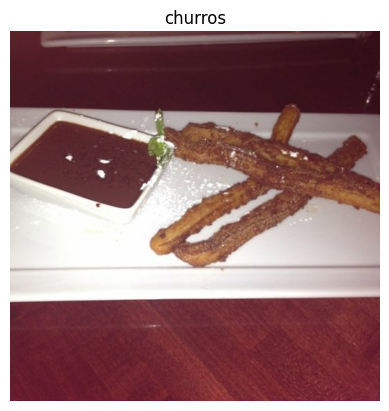

In [22]:
# Plot
import matplotlib.pyplot as plt
plt.imshow(image)
plt.title(class_names[labels.numpy()])
plt.axis("off")

## Create preprocessing functions for our data

Neural Networks perform best when data is in a certain way (eg.batched,normalized,etc)

However, not all data (including data from tensorflow Datasets) comes like this.


In [23]:
# Make a function for preprocessing images
def preprocess_img(image,label,img_shape=224):
  image=tf.image.resize(image,[img_shape,img_shape])
  return tf.cast(image,tf.float32),label

In [24]:
# Preprocess a single sample iamge and check the output
preprocessed_image=preprocess_img(image,labels)[0]
print(f"Image shape after preprocessing: {preprocessed_image.shape}")
print(f"Datatype after preprocessing: {preprocessed_image.dtype}")

Image shape after preprocessing: (224, 224, 3)
Datatype after preprocessing: <dtype: 'float32'>


## Batch and prepare datasets

In [25]:
# Map preprocessing function to train data (and parallelize)
train_data=train_data.map(map_func=preprocess_img,num_parallel_calls=tf.data.AUTOTUNE)

# Shuffle train data and turn it into batches and prefetch it
train_data=train_data.shuffle(buffer_size=1000).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

# Map preprocessing function to test data (and parallelize)
test_data=test_data.map(map_func=preprocess_img,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)


In [26]:
train_data,test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

## Create modelling callbacks


In [ ]:
checkpoint_path="model_checkpoint/cp.weights.h5"
model_checkpoint=tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path,
                                                    monitor="val_acc",
                                                     save_best_only=True,
                                                     save_weights_only=True,
                                                     verbose=0)

## Setup mixed precision training

In [ ]:
# Turn on mixed precision training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

In [ ]:
mixed_precision.global_policy

<function keras.src.dtype_policies.dtype_policy.dtype_policy()>

## Training a feature extraction model

In [ ]:
from tensorflow.keras import layers

# Create base model
input_shape = (224, 224, 3)
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable = False # freeze base model layers

# Create Functional model
inputs = layers.Input(shape=input_shape, name="input_layer")
x = base_model(inputs, training=False) # set base_model to inference mode only
x = layers.GlobalAveragePooling2D(name="pooling_layer")(x)
x = layers.Dense(len(class_names))(x) # want one output neuron per class
# Separate activation of output layer so we can output float32 activations
outputs = layers.Activation("softmax", dtype=tf.float32, name="softmax_float32")(x)
model = tf.keras.Model(inputs, outputs)

# Compile the model
model.compile(loss="sparse_categorical_crossentropy", # Use sparse_categorical_crossentropy when labels are *not* one-hot
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pooling_layer                   │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,048,693 (23.07 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

## Checking layer dtype policies(are we using mixed precision)


In [ ]:
# Check the dtype_policy attributes of layers in our model
for layer in model.layers:
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy) # Check the dtype policy of layers

input_layer True float32 <DTypePolicy "mixed_float16">
efficientnetv2-b0 False float32 <DTypePolicy "mixed_float16">
pooling_layer True float32 <DTypePolicy "mixed_float16">
dense True float32 <DTypePolicy "mixed_float16">
softmax_float32 True float32 <DTypePolicy "float32">


In [ ]:
# Check the layers in the base model and see what dtype policy they're using
for layer in model.layers[1].layers[:20]: # only check the first 20 layers to save output space
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer False float32 <DTypePolicy "mixed_float16">
rescaling False float32 <DTypePolicy "mixed_float16">
normalization False float32 <DTypePolicy "mixed_float16">
stem_conv False float32 <DTypePolicy "mixed_float16">
stem_bn False float32 <DTypePolicy "mixed_float16">
stem_activation False float32 <DTypePolicy "mixed_float16">
block1a_project_conv False float32 <DTypePolicy "mixed_float16">
block1a_project_bn False float32 <DTypePolicy "mixed_float16">
block1a_project_activation False float32 <DTypePolicy "mixed_float16">
block2a_expand_conv False float32 <DTypePolicy "mixed_float16">
block2a_expand_bn False float32 <DTypePolicy "mixed_float16">
block2a_expand_activation False float32 <DTypePolicy "mixed_float16">
block2a_project_conv False float32 <DTypePolicy "mixed_float16">
block2a_project_bn False float32 <DTypePolicy "mixed_float16">
block2b_expand_conv False float32 <DTypePolicy "mixed_float16">
block2b_expand_bn False float32 <DTypePolicy "mixed_float16">
block2b_expand_ac

## Fit the model

In [ ]:
# Turn off all warnings except for errors
tf.get_logger().setLevel('ERROR')

# Fit the model with callbacks
history_1 = model.fit(train_data,
                       epochs=5,
                       steps_per_epoch=len(train_data),
                        validation_data=test_data,
                       validation_steps=int(0.15 * len(test_data)),
                        callbacks=[model_checkpoint])

Epoch 1/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4626 - loss: 2.3503

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):


2368/2368 ━━━━━━━━━━━━━━━━━━━━ 246s 82ms/step - accuracy: 0.4627 - loss: 2.3501 - val_accuracy: 0.6883 - val_loss: 1.1783
Epoch 2/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 156s 65ms/step - accuracy: 0.6541 - loss: 1.3424 - val_accuracy: 0.7233 - val_loss: 1.0406
Epoch 3/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 158s 65ms/step - accuracy: 0.6902 - loss: 1.1849 - val_accuracy: 0.7407 - val_loss: 0.9840
Epoch 4/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 160s 67ms/step - accuracy: 0.7114 - loss: 1.0895 - val_accuracy: 0.7333 - val_loss: 0.9814
Epoch 5/5
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 167s 69ms/step - accuracy: 0.7258 - loss: 1.0377 - val_accuracy: 0.7471 - val_loss: 0.9486


In [ ]:
model.evaluate(test_data)

790/790 ━━━━━━━━━━━━━━━━━━━━ 63s 80ms/step - accuracy: 0.7441 - loss: 0.9495


[0.9496507048606873, 0.7419009804725647]

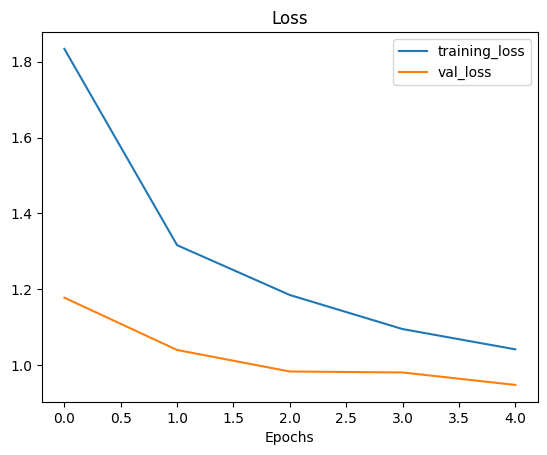

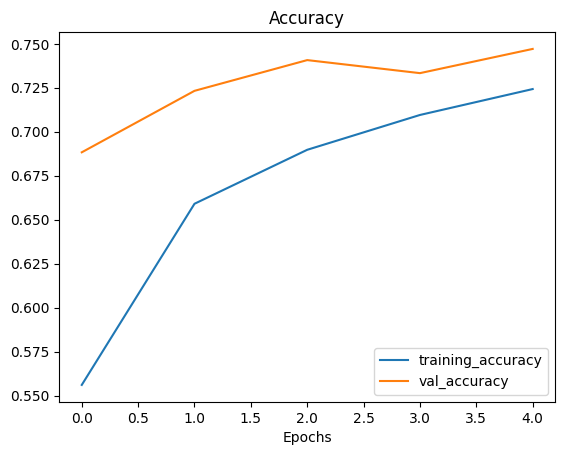

In [ ]:
plot_loss_curves(history_1)

## Fine Tuning

In [ ]:
base_model.trainable=True

# Refreeze every layer except the last 5
for layer in base_model.layers[:-10]:
  layer.trainable=False

# ReCompile the model
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy"])

In [ ]:
# Refit the model
initial_epochs=5
fined_tuned_epochs=initial_epochs+5
history_2=model.fit(train_data,
          epochs=fined_tuned_epochs,
          validation_data=test_data,
          validation_steps=int(0.15*len(test_data)),
          initial_epoch=history_1.epoch[-1])

Epoch 5/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 238s 81ms/step - accuracy: 0.7202 - loss: 1.0755 - val_accuracy: 0.7601 - val_loss: 0.8857
Epoch 6/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 155s 65ms/step - accuracy: 0.7604 - loss: 0.8983 - val_accuracy: 0.7704 - val_loss: 0.8360
Epoch 7/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 154s 64ms/step - accuracy: 0.7822 - loss: 0.8193 - val_accuracy: 0.7778 - val_loss: 0.8268
Epoch 8/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 156s 65ms/step - accuracy: 0.7964 - loss: 0.7708 - val_accuracy: 0.7828 - val_loss: 0.7920
Epoch 9/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 159s 66ms/step - accuracy: 0.8058 - loss: 0.7320 - val_accuracy: 0.7812 - val_loss: 0.7947
Epoch 10/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 161s 67ms/step - accuracy: 0.8159 - loss: 0.6867 - val_accuracy: 0.7860 - val_loss: 0.7842


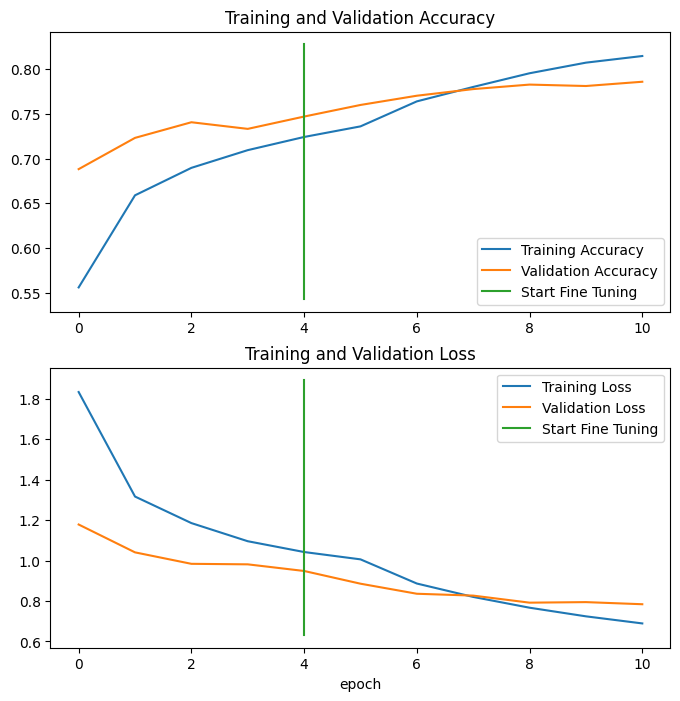

In [ ]:
compare_historys(history_1,history_2)

In [ ]:
model.evaluate(test_data)

790/790 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.7825 - loss: 0.7870


[0.7862582802772522, 0.7807128429412842]

In [ ]:
# Save the model
model.save("food_vision.keras")

In [ ]:
# Save the model
model.save("food_vision.h5")

## Fine tune again

In [ ]:
model.load_weights(checkpoint_path)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 30 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model.evaluate(test_data)

790/790 ━━━━━━━━━━━━━━━━━━━━ 49s 61ms/step - accuracy: 0.7443 - loss: 0.9490


[0.949650764465332, 0.7419009804725647]

In [ ]:
base_model.trainable=True

# Refreeze every layer except the last 20
for layer in base_model.layers[:-20]:
  layer.trainable=False

# ReCompile the model
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy"])

In [ ]:
# Refit the model
initial_epochs=5
fined_tuned_epochs=initial_epochs+5
history_3=model.fit(train_data,
          epochs=fined_tuned_epochs,
          validation_data=test_data,
          validation_steps=int(0.15*len(test_data)),
          initial_epoch=history_1.epoch[-1])

Epoch 5/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 242s 83ms/step - accuracy: 0.7204 - loss: 1.0740 - val_accuracy: 0.7606 - val_loss: 0.8756
Epoch 6/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 160s 67ms/step - accuracy: 0.7632 - loss: 0.8949 - val_accuracy: 0.7685 - val_loss: 0.8496
Epoch 7/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 159s 66ms/step - accuracy: 0.7810 - loss: 0.8276 - val_accuracy: 0.7746 - val_loss: 0.8240
Epoch 8/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 161s 67ms/step - accuracy: 0.7956 - loss: 0.7713 - val_accuracy: 0.7799 - val_loss: 0.8020
Epoch 9/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 203s 67ms/step - accuracy: 0.8075 - loss: 0.7247 - val_accuracy: 0.7810 - val_loss: 0.7932
Epoch 10/10
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 163s 67ms/step - accuracy: 0.8174 - loss: 0.6823 - val_accuracy: 0.7873 - val_loss: 0.7755


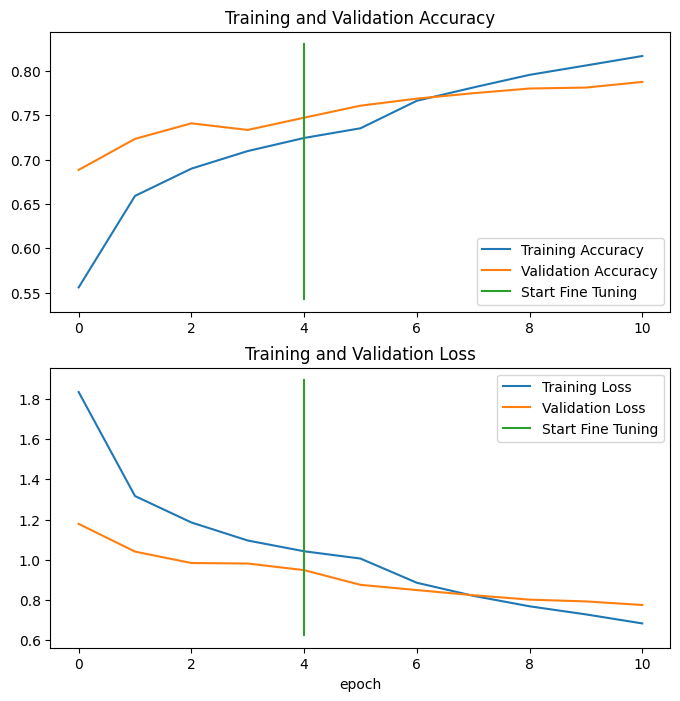

In [ ]:
compare_historys(history_1,history_3)

In [ ]:
# Save the model
model.save("food_vision.keras")
model.save("food_vision.h5")

In [33]:
model.evaluate(test_data)

790/790 ━━━━━━━━━━━━━━━━━━━━ 70s 65ms/step - accuracy: 0.7811 - loss: 0.7882


[0.7882813215255737, 0.779564380645752]

## Lets make some prediction

In [1]:
import tensorflow as tf

In [2]:
model=tf.keras.models.load_model("food_vision.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [3]:
## Getting the images
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/custom_food_images.zip

--2025-09-27 11:35:39--  https://storage.googleapis.com/ztm_tf_course/food_vision/custom_food_images.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.99.207, 142.250.107.207, 142.251.188.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.99.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13192985 (13M) [application/zip]
Saving to: ‘custom_food_images.zip’

custom_food_images. 100%[===================>]  12.58M  51.1MB/s    in 0.2s    

2025-09-27 11:35:40 (51.1 MB/s) - ‘custom_food_images.zip’ saved [13192985/13192985]



In [8]:
unzip_data("custom_food_images.zip")

In [9]:
import os
images=["custom_food_images/"+img_path for img_path in os.listdir("custom_food_images")]



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


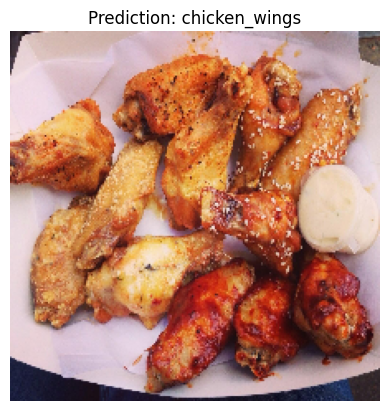

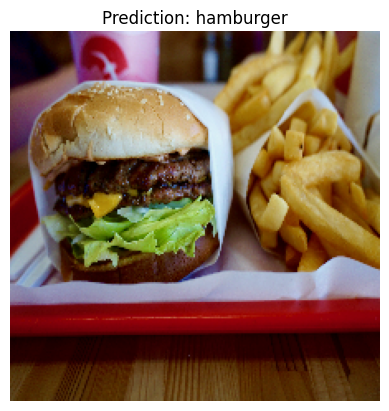

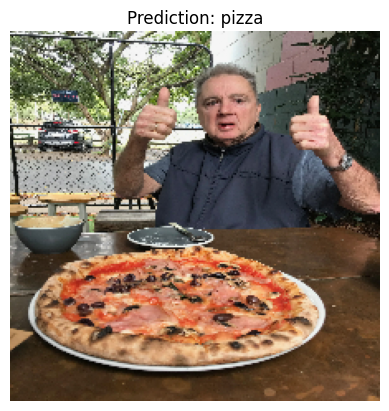

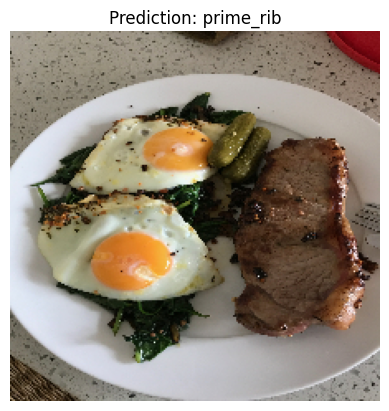

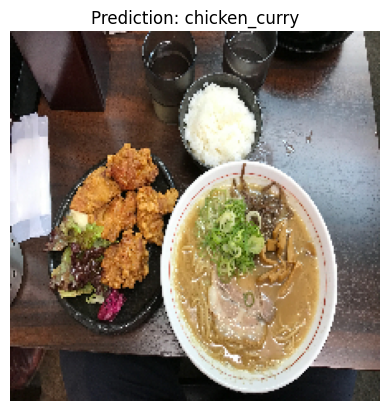

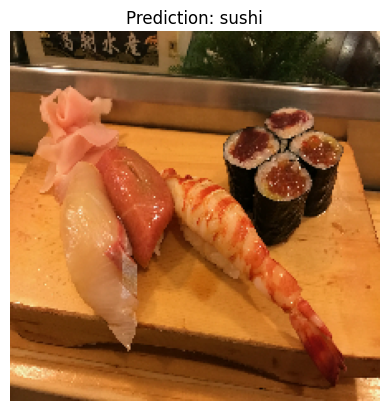

In [27]:
for img in images:
  img=load_and_prep_image(img,scale=False)
  pred_prob=model.predict(tf.expand_dims(img,axis=0))
  pred_class=class_names[pred_prob.argmax()]

  plt.figure()
  plt.imshow(img/255.)
  plt.title(f"Prediction: {pred_class}")
  plt.axis(False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

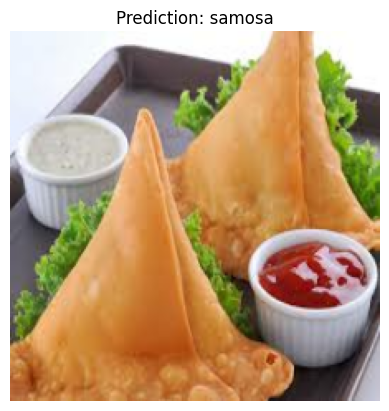

In [44]:
img=load_and_prep_image("samosa2.jfif",scale=False)
pred_prob=model.predict(tf.expand_dims(img,axis=0))
pred_class=class_names[pred_prob.argmax()]

plt.figure()
plt.imshow(img/255.)
plt.title(f"Prediction: {pred_class}")
plt.axis(False)